In [1]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import hydrogenbonds
import matplotlib.pyplot as plt
import nglview as nv
import ipywidgets


In [2]:
%matplotlib notebook

In [3]:
# Loads just a .gro single-frame file and checks if there are positions and velocities
grofile = "mdrun.gro"
xtcfile = "mdrun_whole.xtc"

uframe = mda.Universe(grofile,xtcfile)
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

True
False


In [4]:
# Loads the data
u = mda.Universe(grofile,xtcfile)
print(np.shape(u.atoms.positions))
print(u.trajectory.ts.has_positions)
print(u.trajectory.ts.has_velocities)

(11588, 3)
True
False


In [5]:
# Turn this on if we want to look at the trajectory
TOTview = nv.show_mdanalysis(u)
TOTview.clear()
TOTview.add_contact(hydrogen_bond=True)
TOTview.add_representation('ball+stick',selection='RNA')
#TOTview.add_representation('surface',selection='SOL')
TOTview.add_representation('licorice',selection='SOL', opacity=0.3)
#TOTview.add_representation('licorice',selection='SOL')
#TOTview.add_representation('ball+stick',selection='NA',radius=0.5)
#TOTview.add_representation('contact',selection='RNA+SOL')
TOTview.camera='orthographic'
TOTview.center()
TOTview

NGLWidget(max_frame=100000)

In [6]:
# Specify coordinates we want
Pterm = u.select_atoms('name P')[0]
O1Pterm = u.select_atoms('name O1P')[0]
O2Pterm = u.select_atoms('name O2P')[0]
NAterm = u.select_atoms('name NA')[0]
len(u.trajectory)

100001

In [7]:
# I am going to attempt to select the frames of the simulation where the ice started to melt 
ts=u.trajectory.ts
window=u.trajectory.ts

In [8]:
# Extract some coordinates (and time)
P_position = []
O1P_position = []
O2P_position = []
NA_position = []
pullforce = []
pullx = []
time = []
for ts in u.trajectory:     # iterate through all frames
    P_position.append(Pterm.position) # end-to-end vector fr
    O1P_position.append(O1Pterm.position)
    O2P_position.append(O2Pterm.position)
    NA_position.append(NAterm.position)
    time.append(u.trajectory.time)
print(np.shape(P_position))
print(np.shape(time))
time = np.array(time)/1e3

xref = np.array(P_position)[0,0]/10
yref = np.array(P_position)[0,1]/10


(100001, 3)
(100001,)


<IPython.core.display.Javascript object>


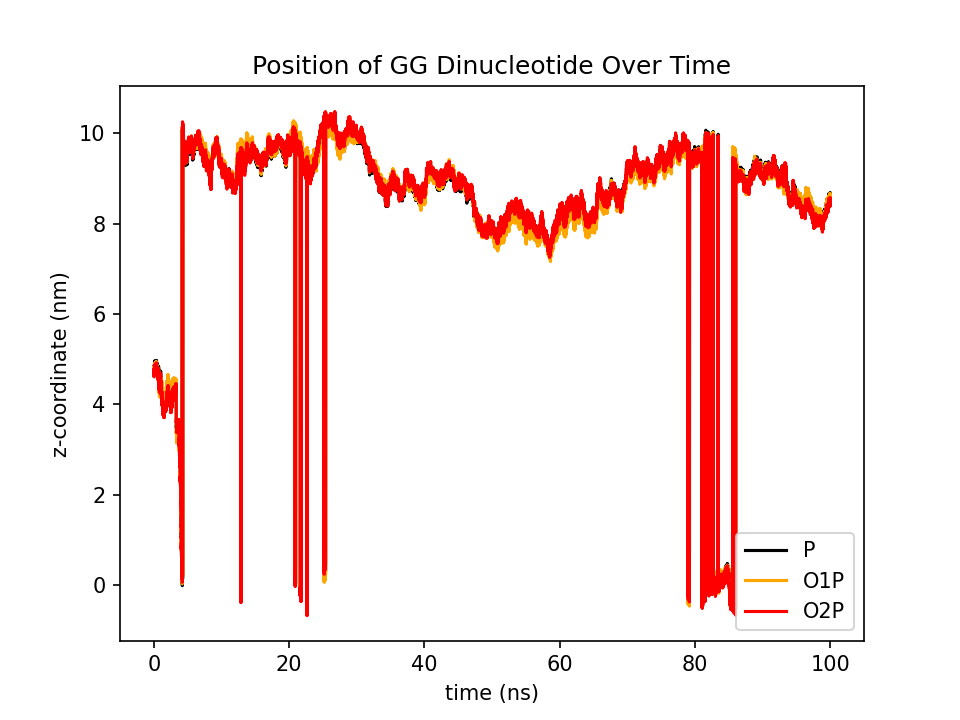

Text(0.5, 1.0, 'Position of GG Dinucleotide Over Time')

In [11]:
plt.figure()
plt.plot(time,np.array(P_position)[:,2]/10,'k',label='P')
plt.plot(time,np.array(O1P_position)[:,2]/10,'orange',label='O1P')
plt.plot(time,np.array(O2P_position)[:,2]/10,'red',label='O2P')
#plt.plot(time,np.array(NA_position)[:,2]/10,'blue',label='NA')
plt.grid(False)
#xmin, xmax = plt.xlim(0,36)
#ymin, ymax = plt.ylim(4.2,5)
plt.xlabel('time (ns)')
plt.ylabel('z-coordinate (nm)')
plt.legend()
plt.title("Position of GG Dinucleotide Over Time")

<IPython.core.display.Javascript object>


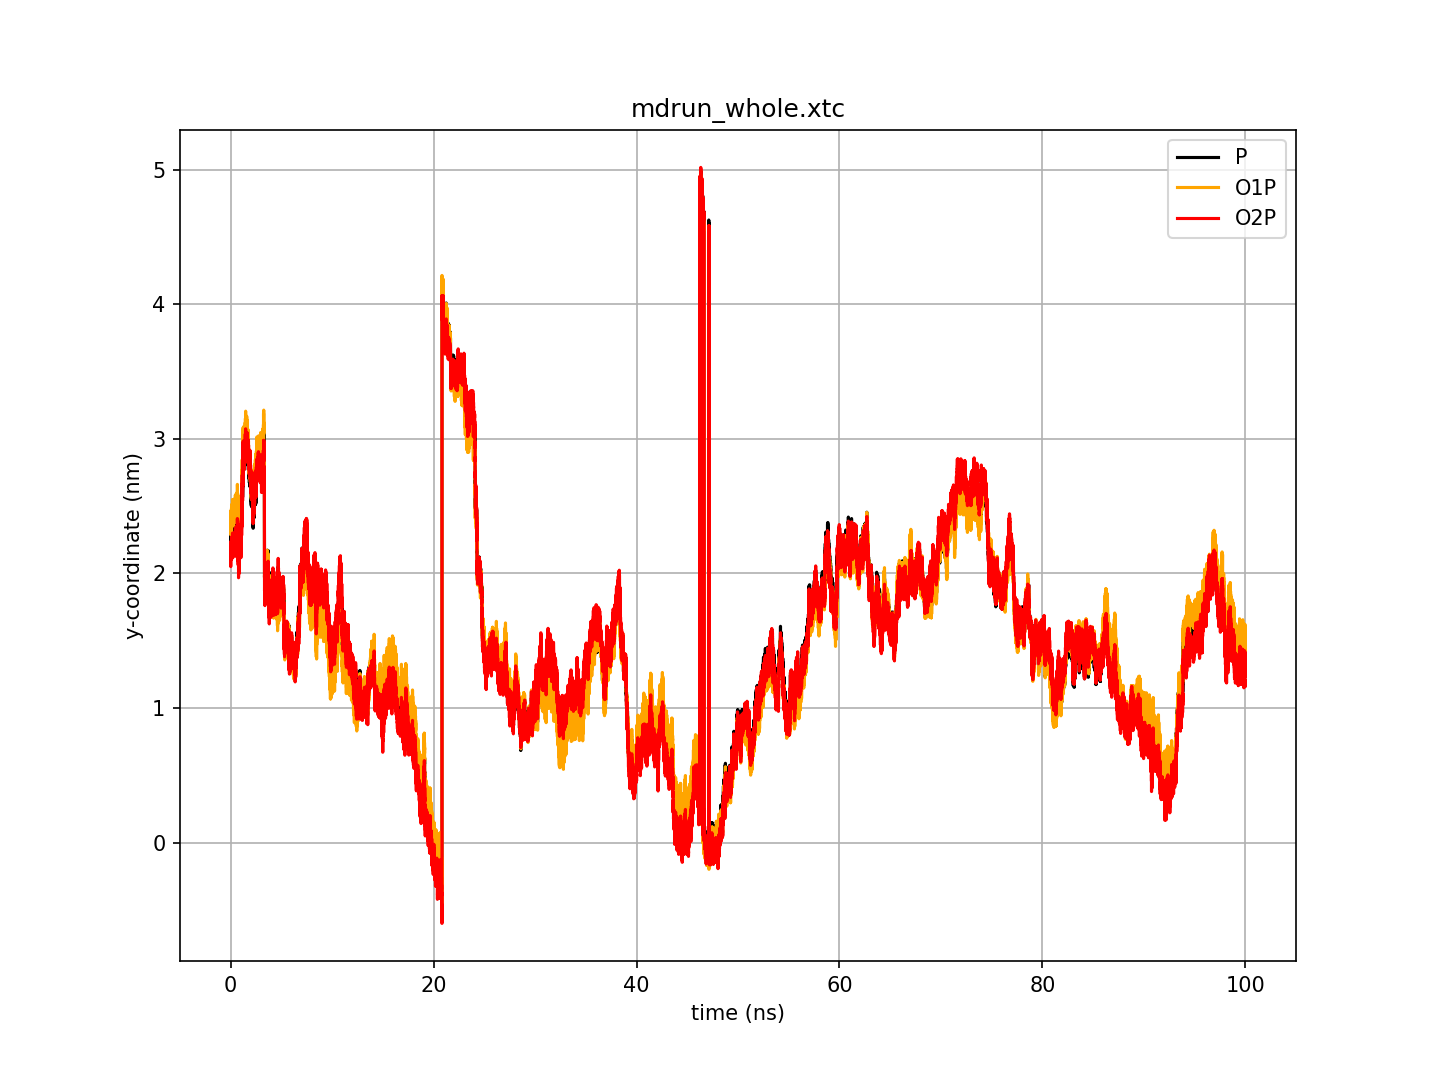

Text(0.5, 1.0, 'mdrun_whole.xtc')

In [10]:
plt.figure()
plt.plot(time,np.array(P_position)[:,1]/10,'k',label='P')
plt.plot(time,np.array(O1P_position)[:,1]/10,'orange',label='O1P')
plt.plot(time,np.array(O2P_position)[:,1]/10,'red',label='O2P')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('y-coordinate (nm)')
plt.legend()
plt.title(xtcfile)

In [51]:
# This sets up creation of a 2-d histogram of solvent water, probility(x,y), integrated over z

# Break out the oxygen atoms of the solvent
OWterm = u.select_atoms('name OW')
print (np.shape(OWterm.positions))

# Extract x- and y-coordinates
OWx = OWterm.positions[:,0]/10; print(np.shape(OWx)) # In nm
OWy = OWterm.positions[:,1]/10; print(np.shape(OWy))# Make the histogram
H, xedges, yedges = np.histogram2d(OWx, OWy, bins=[75,75])

(2880, 3)
(2880,)
(2880,)


/home/chemistry/.local/lib/python3.9/site-packages/MDAnalysis/core/selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


<IPython.core.display.Javascript object>


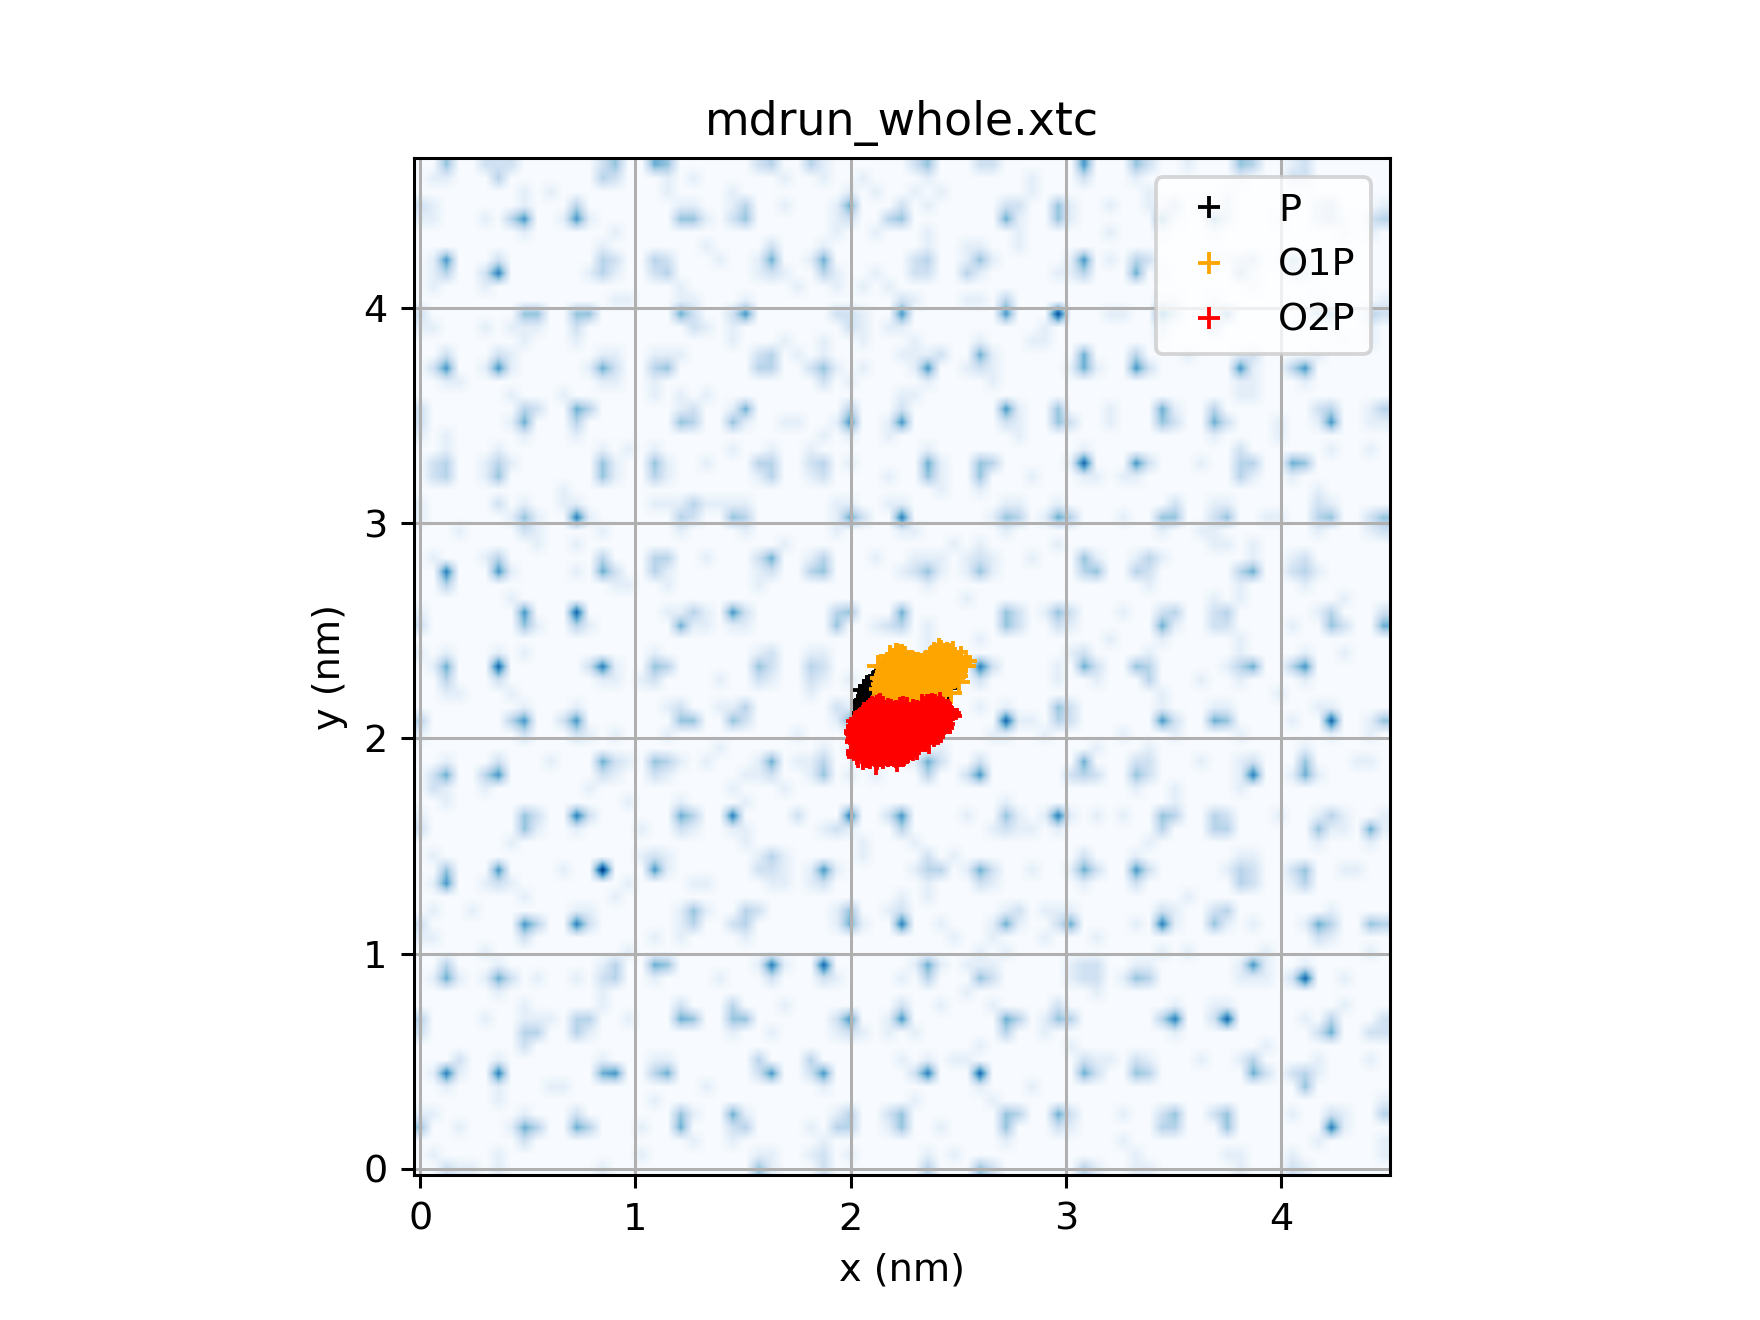

In [52]:
# Graphics
plt.figure()
plt.plot(np.array(P_position)[:,0]/10,np.array(P_position)[:,1]/10,'k+',label='P')
plt.plot(np.array(O1P_position)[:,0]/10,np.array(O1P_position)[:,1]/10,'+',color='orange',label='O1P')
plt.plot(np.array(O2P_position)[:,0]/10,np.array(O2P_position)[:,1]/10,'+',color='red',label='O2P')

# Plot the histogram of where the water molecules are
axislims = np.array(plt.axis())

expandby = 0.25
axislims[0]-=expandby
axislims[1]+=expandby
axislims[2]-=expandby
axislims[3]+=expandby
plt.imshow(H, cmap='Blues', interpolation='bilinear', origin='lower', \
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.legend()
plt.title(xtcfile)
plt.grid(True)
# # width = 1.0
# # xlleft = 2.2
# # ylleft = 1.6
# plt.axes().set_aspect('equal')


<IPython.core.display.Javascript object>


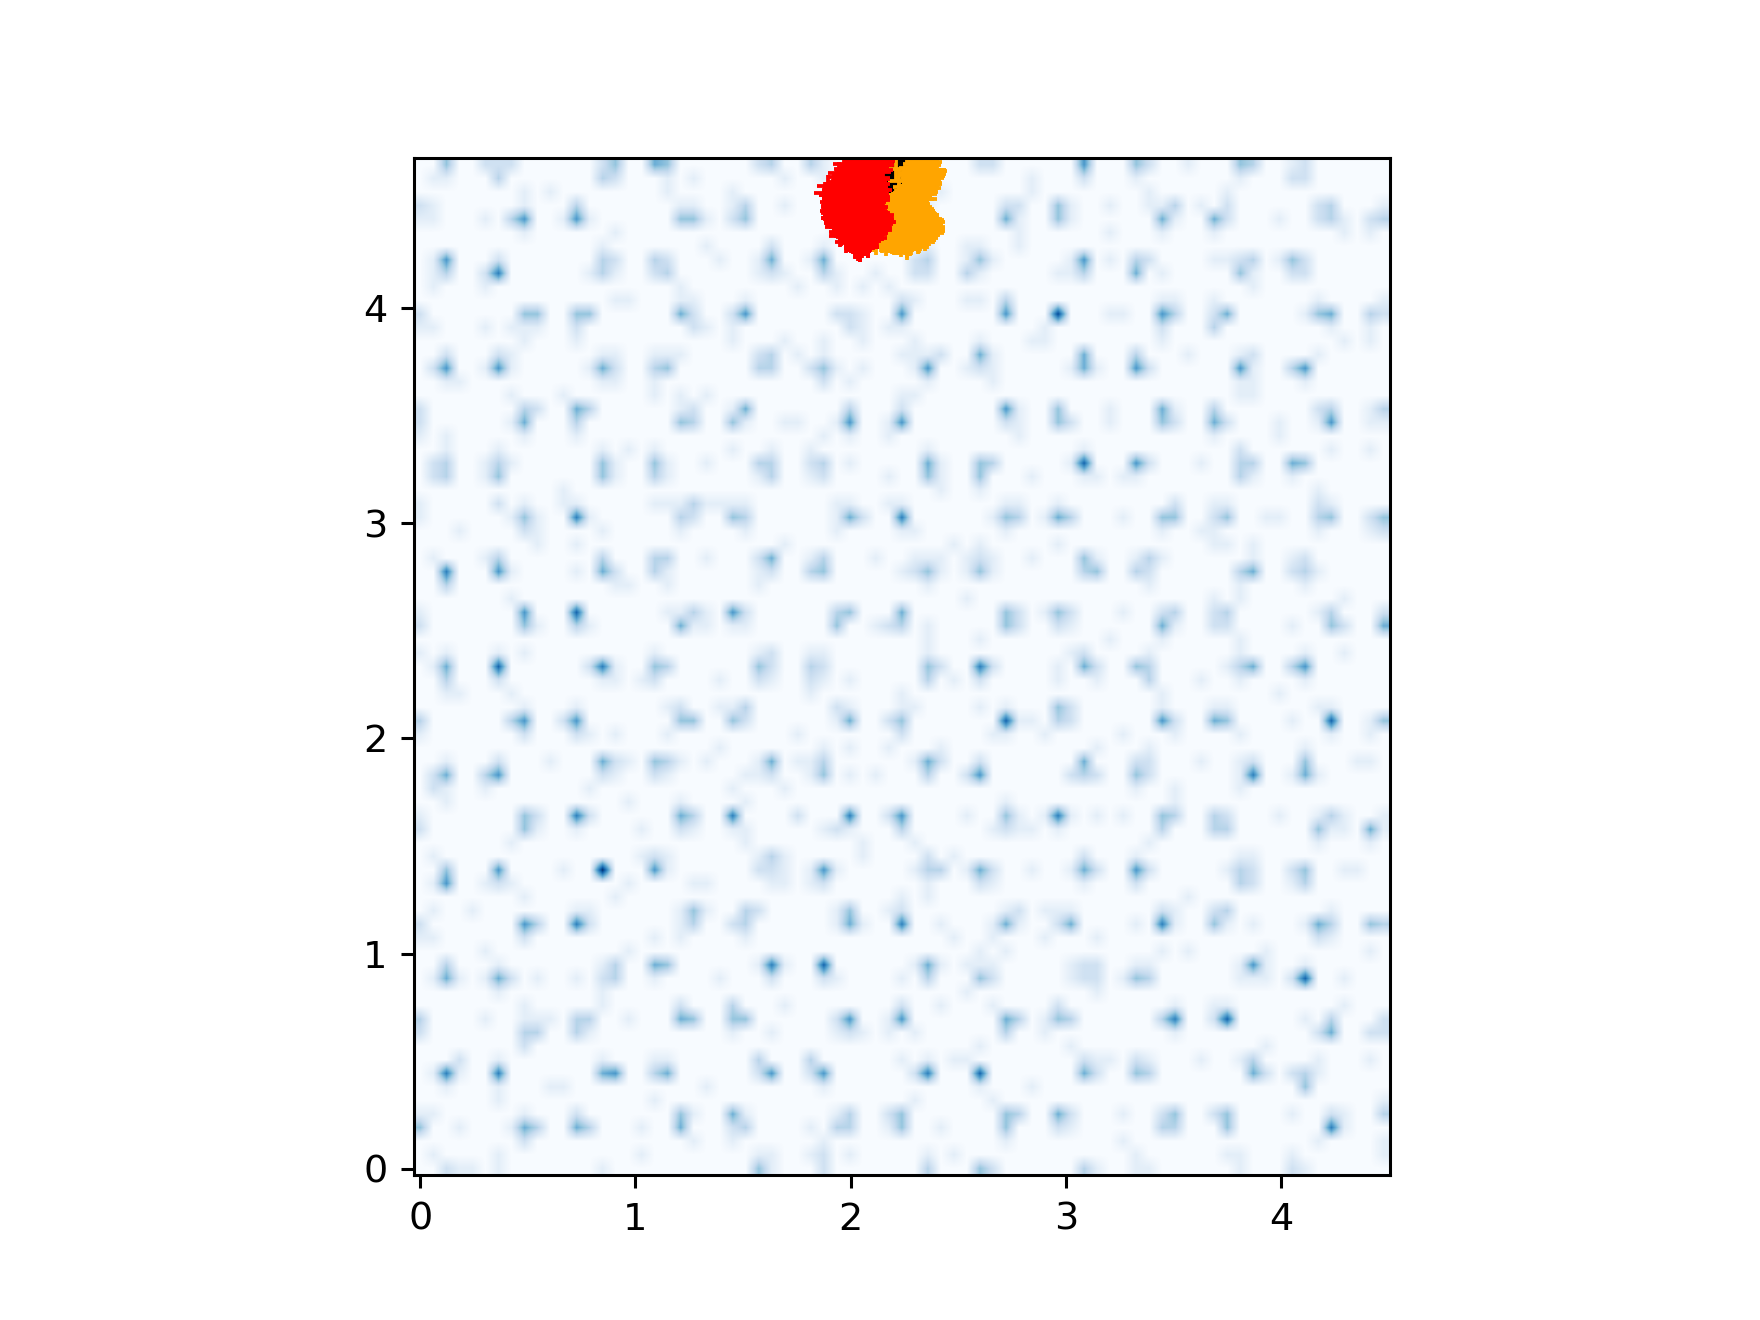

AttributeError: module 'matplotlib.pyplot' has no attribute 'zlabel'

In [53]:
# Graphics
plt.figure()
plt.plot(np.array(P_position)[:,1]/10,np.array(P_position)[:,2]/10,'k+',label='P')
plt.plot(np.array(O1P_position)[:,1]/10,np.array(O1P_position)[:,2]/10,'+',color='orange',label='O1P')
plt.plot(np.array(O2P_position)[:,1]/10,np.array(O2P_position)[:,2]/10,'+',color='red',label='O2P')

# Plot the histogram of where the water molecules are
axislims = np.array(plt.axis())

expandby = 0.25
axislims[0]-=expandby
axislims[1]+=expandby
axislims[2]-=expandby
axislims[3]+=expandby
plt.imshow(H, cmap='Blues', interpolation='bilinear', origin='lower', \
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
plt.zlabel('z (nm)')
plt.ylabel('y (nm)')
plt.legend()
plt.title(xtc)
plt.grid(True)
# # width = 1.0
# # xlleft = 2.2
# # ylleft = 1.6
# plt.axes().set_aspect('equal')
